In [1]:
# Jupyter Notebook
import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix
from implicit.als import AlternatingLeastSquares
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("./ml-latest/ml-latest/ratings.csv")

# Display the first few rows of the dataset
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [2]:
# Convert ratings to a sparse matrix
user_ids = {id: i for i, id in enumerate(df['userId'].unique())}
movie_ids = {id: i for i, id in enumerate(df['movieId'].unique())}
rows = df['userId'].map(user_ids)
cols = df['movieId'].map(movie_ids)
ratings = coo_matrix((df['rating'], (rows, cols)))

# Display the shape of the sparse matrix
print(f"Sparse matrix shape: {ratings.shape}")

Sparse matrix shape: (200948, 84432)


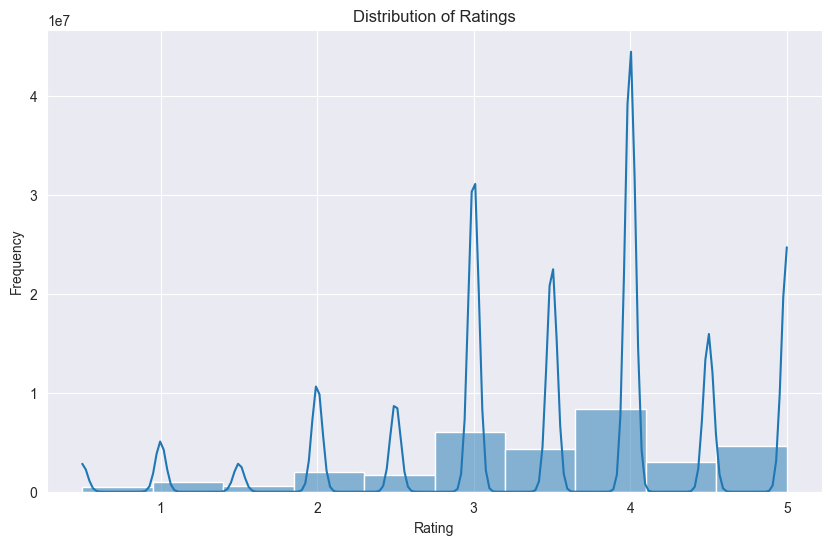

In [3]:
# Visualize the distribution of ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], bins=10, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [1]:
# Train ALS Model
model = AlternatingLeastSquares(factors=64, regularization=0.1, iterations=15)
model.fit(ratings)

# Save model factors
np.save("user_factors.npy", model.user_factors)
np.save("movie_factors.npy", model.item_factors)

# Display the shape of the user and movie factors
print(f"User factors shape: {model.user_factors.shape}")
print(f"Movie factors shape: {model.item_factors.shape}")

NameError: name 'AlternatingLeastSquares' is not defined

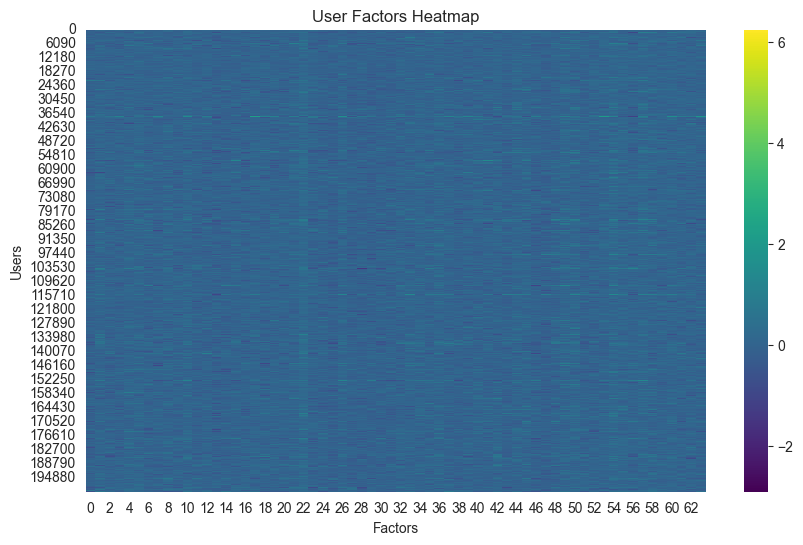

In [5]:
# Visualize the user factors
plt.figure(figsize=(10, 6))
sns.heatmap(model.user_factors, cmap="viridis")
plt.title("User Factors Heatmap")
plt.xlabel("Factors")
plt.ylabel("Users")
plt.show()

Text(95.72222222222221, 0.5, 'Movies')

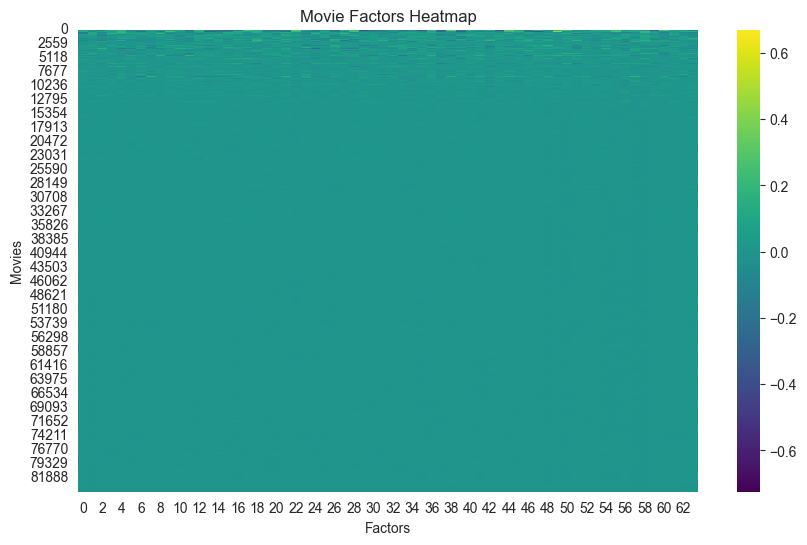

In [6]:
# Visualize the movie factors
plt.figure(figsize=(10, 6))
sns.heatmap(model.item_factors, cmap="viridis")
plt.title("Movie Factors Heatmap")
plt.xlabel("Factors")
plt.ylabel("Movies")
